In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("Superstore.csv")

In [2]:
print(df.info())
df =df.drop(columns=["Row ID","Customer ID","Customer Name","Product ID","Product Name","Postal Code","Order ID"]
           )
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst= True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst= True)
df["Ship Mode"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

C:\Users\Ayush\AppData\Local\Temp\ipykernel_24652\4294405585.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst= True)
C:\Users\Ayush\AppData\Local\Temp\ipykernel_24652\4294405585.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst= True)


array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [3]:
# Creating time based 
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["DayofWeek"] = df["Order Date"].dt.dayofweek

In [4]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales["lag_1"] = daily_sales["Sales"].shift(1)
daily_sales["lag_7"] = daily_sales["Sales"].shift(7)

df = df.merge(
    daily_sales[["Order Date", "lag_1", "lag_7"]],
    on="Order Date",
    how="left"
)
df["profit_margin"] = df["Profit"] / (df["Sales"] + 1)

df["discount_quantity"] = df["Discount"] * df["Quantity"]

df = df.sort_values("Order Date")
df = df.dropna().reset_index(drop=True)
df = df.drop(columns=["Country","City","State","Year","Ship Date","Ship Mode", "Segment"])


In [5]:
df.isnull().sum()

df.head(20)

,Order Date,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Month,Day,DayofWeek,lag_1,lag_7,profit_margin,discount_quantity
0,2014-01-10,West,Office Supplies,Fasteners,4.710,1,0.0,0.0000,1,10,4,469.436,468.900,0.000000,0.0
1,2014-01-11,East,Office Supplies,Paper,167.940,3,0.0,82.2906,1,11,5,4.710,2203.151,0.487100,0.0
2,2014-01-11,East,Office Supplies,Appliances,76.120,2,0.0,22.0748,1,11,5,4.710,2203.151,0.286240,0.0
3,2014-01-11,East,Office Supplies,Appliances,533.940,3,0.0,154.8426,1,11,5,4.710,2203.151,0.289458,0.0
4,2014-01-11,Central,Office Supplies,Paper,15.696,3,0.2,5.1012,1,11,5,4.710,2203.151,0.305534,0.6
5,2014-01-11,South,Technology,Phones,978.840,9,0.2,110.1195,1,11,5,4.710,2203.151,0.112385,1.8
6,2014-01-11,South,Office Supplies,Storage,69.520,2,0.0,19.4656,1,11,5,4.710,2203.151,0.276029,0.0
7,2014-01-11,South,Office Supplies,Art,5.640,3,0.0,1.6356,1,11,5,4.710,2203.151,0.246325,0.0
8,2014-01-11,East,Furniture,Furnishings,31.680,6,0.0,9.8208,1,11,5,4.710,2203.151,0.300514,0.0
9,2014-01-11,East,Furniture,Furnishings,68.704,2,0.2,16.3172,1,11,5,4.710,2203.151,0.234093,0.4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order Date         9954 non-null   datetime64[ns]
 1   Region             9954 non-null   object        
 2   Category           9954 non-null   object        
 3   Sub-Category       9954 non-null   object        
 4   Sales              9954 non-null   float64       
 5   Quantity           9954 non-null   int64         
 6   Discount           9954 non-null   float64       
 7   Profit             9954 non-null   float64       
 8   Month              9954 non-null   int32         
 9   Day                9954 non-null   int32         
 10  DayofWeek          9954 non-null   int32         
 11  lag_1              9954 non-null   float64       
 12  lag_7              9954 non-null   float64       
 13  profit_margin      9954 non-null   float64       
 14  discount

# EDA

<Axes: ylabel='Sales'>

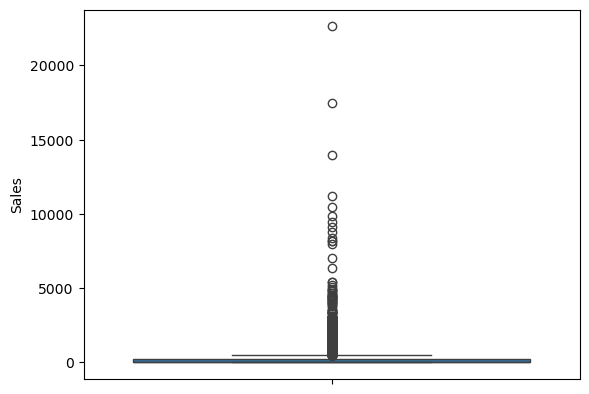

In [7]:
sns.boxplot(
    y = df["Sales"]
)

Text(0.5, 1.0, 'Category vs Sales')

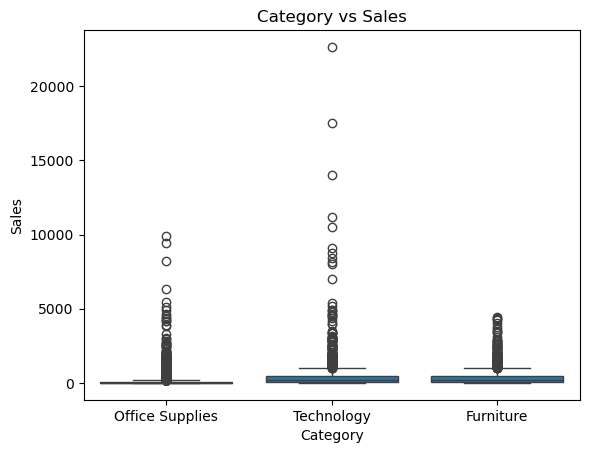

In [8]:
sns.boxplot(
    data = df,
    x= "Category",
    y = "Sales"
)
plt.title("Category vs Sales")
# Mostly sales are from Technology category thus have high demand of tech products

<Axes: xlabel='Sub-Category', ylabel='Sales'>

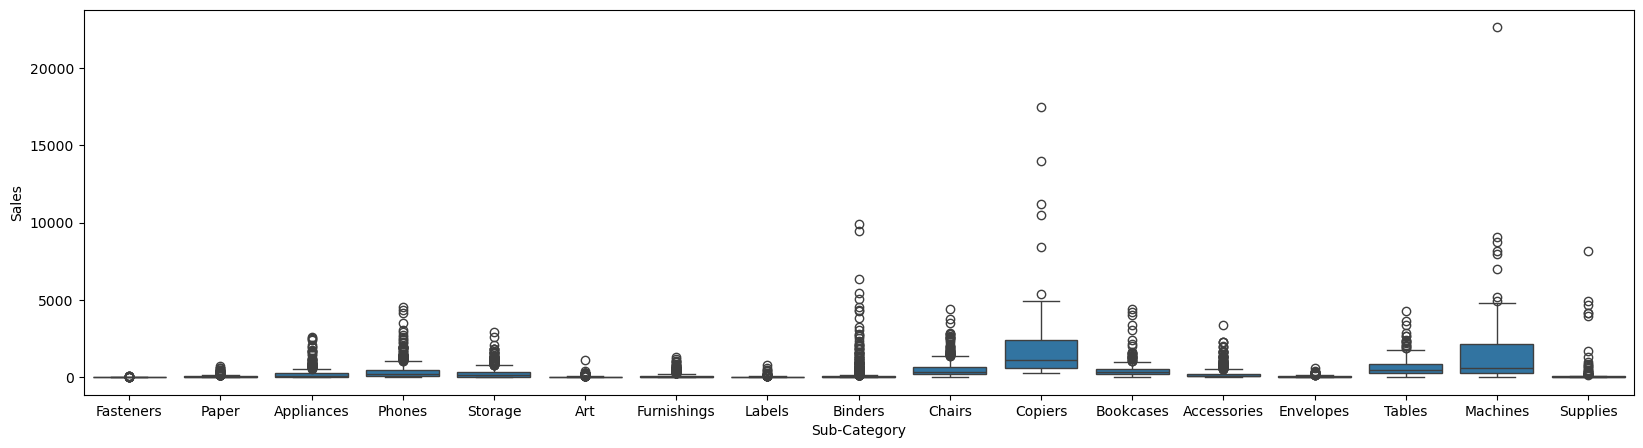

In [9]:
plt.figure(figsize=(20,5))
sns.boxplot(
    data = df,
    x = "Sub-Category",
    y = "Sales",

)
# copier has highest demand while machines also have demand with sudden spike

(0.0, 5000.0)

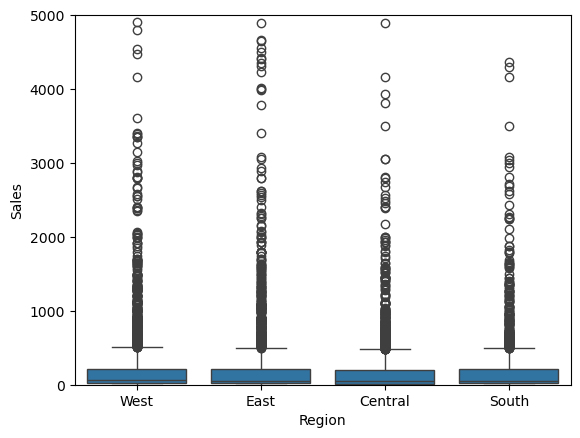

In [10]:
sns.boxplot(
    data = df,
    x= "Region",
    y = "Sales"
)
plt.ylim(0,5000)
# Sales across regions are generally consistent, but overall revenue is heavily influenced by occasional high-value transactions, especially in the South and West regions.

Text(0.5, 1.0, 'Sales Distribution')

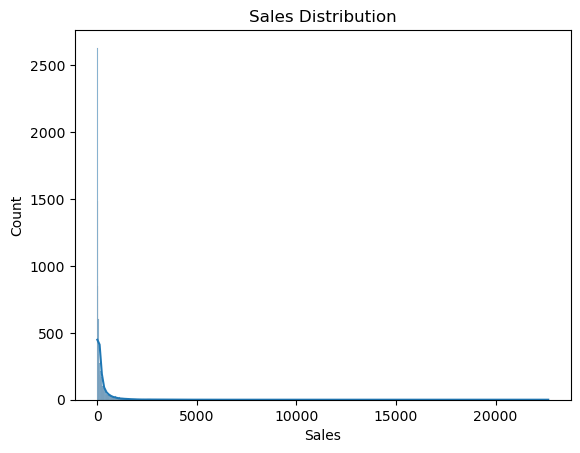

In [11]:
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution")

Text(0.5, 1.0, 'Sales Distribution on Discount')

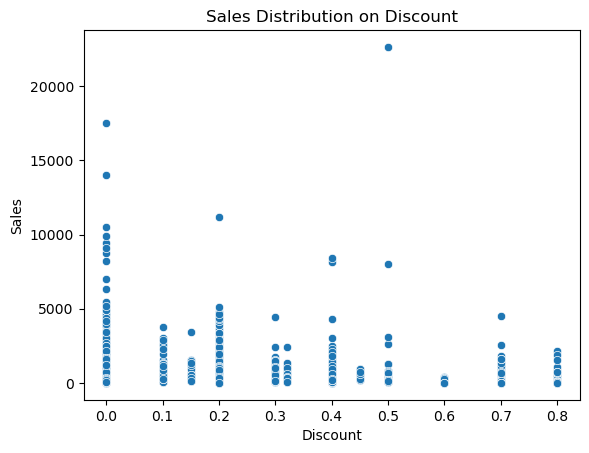

In [12]:
sns.scatterplot(
    data = df,
    x= "Discount", 
    y= "Sales"
)
plt.title("Sales Distribution on Discount")
# Sales are not strongly driven by discounts, and high discounts do not consistently result in higher revenue, indicating the need for optimized discount strategies.

<Axes: xlabel='Quantity', ylabel='Sales'>

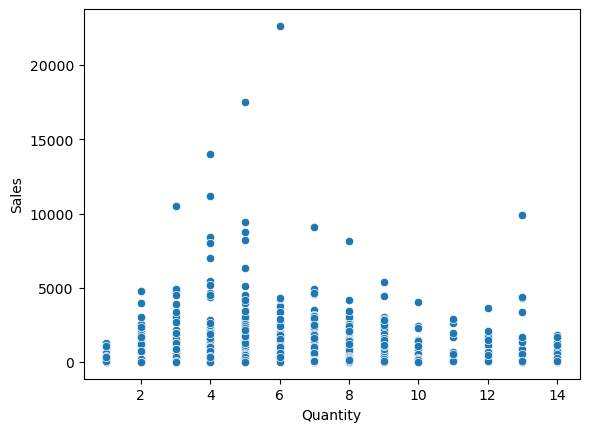

In [13]:
sns.scatterplot(
    data = df,
    x= "Quantity",
    y= "Sales"
)
# Quantity has a limited impact on sales, as high revenue is often generated from moderate-sized orders rather than very large quantities.

<Axes: xlabel='Profit', ylabel='Sales'>

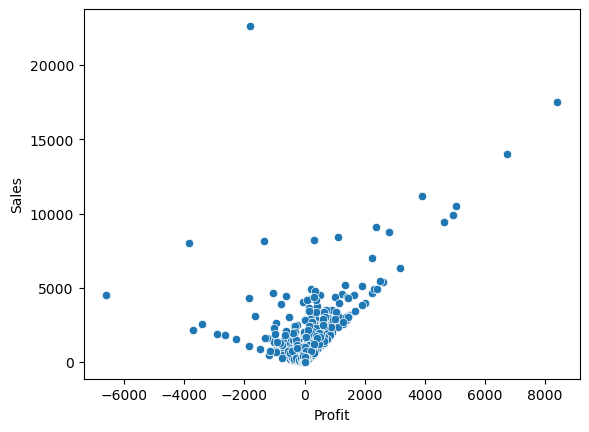

In [14]:
sns.scatterplot(
    data = df,
    x= "Profit",
    y= "Sales"
)
# Although sales and profit are positively correlated, a significant number of transactions generate low or negative profit, indicating inefficiencies in pricing or discount strategies.

<Axes: xlabel='Month', ylabel='Sales'>

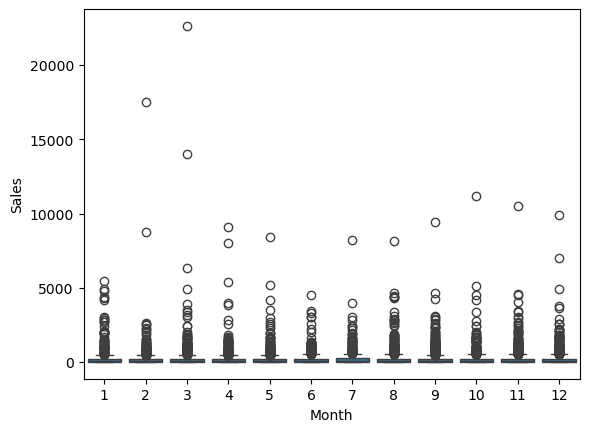

In [15]:
sns.boxplot(
    data = df,
    x = "Month",
    y = "Sales"
)
# Due to festive season (march(highest), sept-december ) have high sales compared to other

<Axes: xlabel='DayofWeek', ylabel='Sales'>

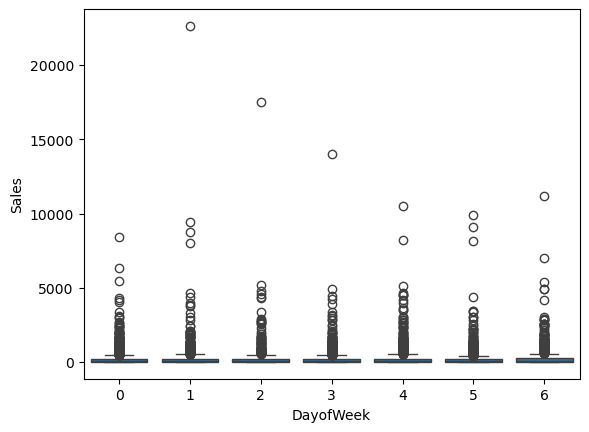

In [16]:
sns.boxplot(
    data = df,
    x = "DayofWeek",
    y = "Sales"
)
# Sales are relatively stable across weekdays, with a slight increase during weekends, indicating limited but noticeable weekly seasonality

                      Sales  Quantity  Discount    Profit     Month       Day  \
Sales              1.000000  0.200431 -0.027741  0.478539 -0.011237  0.008037   
Quantity           0.200431  1.000000  0.008576  0.065817  0.009174  0.019074   
Discount          -0.027741  0.008576  1.000000 -0.219289 -0.001909 -0.005605   
Profit             0.478539  0.065817 -0.219289  1.000000 -0.013939  0.003036   
Month             -0.011237  0.009174 -0.001909 -0.013939  1.000000  0.147778   
Day                0.008037  0.019074 -0.005605  0.003036  0.147778  1.000000   
DayofWeek         -0.005672  0.002738  0.009279 -0.003583 -0.002833  0.038779   
lag_1              0.003863  0.002410 -0.000094 -0.002985  0.072420  0.055853   
lag_7              0.002596  0.005325 -0.008573  0.013947  0.106556  0.167092   
profit_margin      0.001724 -0.004779 -0.859437  0.243706  0.002992  0.009175   
discount_quantity  0.037060  0.355621  0.813793 -0.209964 -0.003111 -0.005767   

                   DayofWee

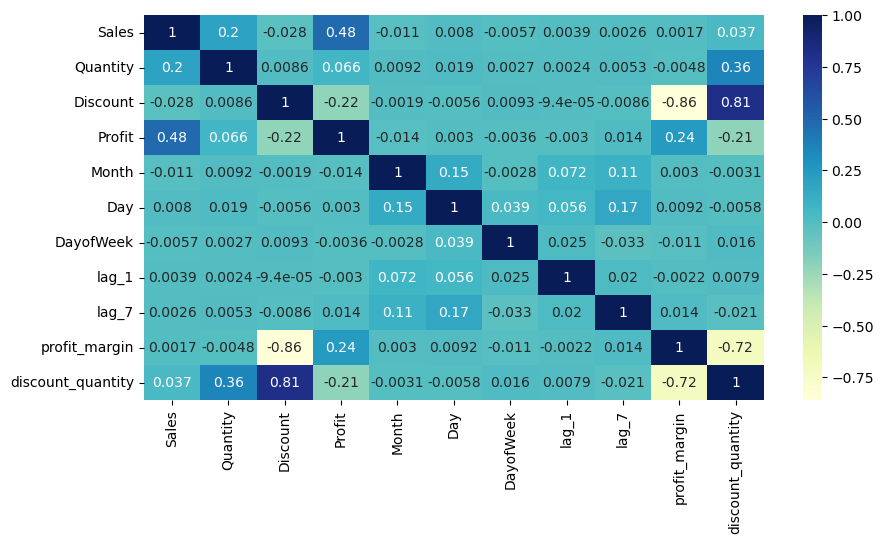

In [17]:
co_mtx = df.corr(numeric_only=True)
plt.figure(figsize=(10,5))
# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()
# discounts increase sales volume but significantly reduce profit margins
# Sales are influenced by both price and quantity, not just volume

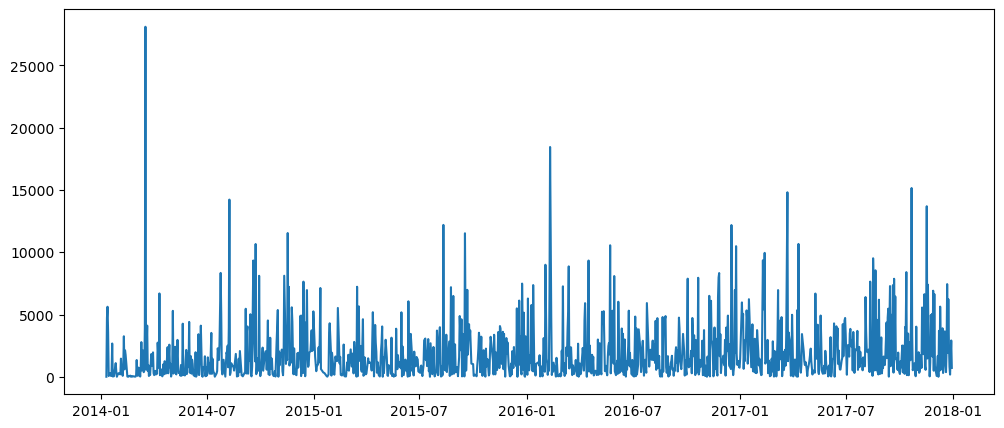

In [18]:
daily = df.groupby("Order Date")["Sales"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily["Order Date"], daily["Sales"])

In [19]:
df = pd.get_dummies(df, columns=["Region","Category","Sub-Category",], drop_first = True, dtype= int)

# Train the Model

In [20]:
#  Train test split
# As we have time series data thus we can't do random split because based on past data we have to predict future insights
df = df.sort_values("Order Date")
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42)
split_index = int(len(df)*0.8)

train = df.iloc[:split_index]  # first 80% data
test = df.iloc[split_index:]   # last 20% data

X_train = train.drop(columns = ["Sales", "Order Date","Day","profit_margin"])
y_train = train["Sales"]

X_test = test.drop(columns = ["Sales", "Order Date","Day","profit_margin"])
y_test = test["Sales"]
X_test.tail()

,Quantity,Discount,Profit,Month,DayofWeek,lag_1,lag_7,discount_quantity,Region_East,Region_South,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
9952,4,0.2,12.1176,12,5,2915.534,1926.776,0.8,1,0,...,0,0,0,0,0,0,0,0,0,0
9948,3,0.2,19.7910,12,5,2915.534,1926.776,0.6,1,0,...,0,0,0,0,0,0,0,0,0,0
9947,2,0.0,56.5110,12,5,2915.534,1926.776,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
9949,7,0.0,2.7279,12,5,2915.534,1926.776,0.0,1,0,...,0,0,0,0,0,0,1,0,0,0
9953,2,0.2,4.5188,12,5,2915.534,1926.776,0.4,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-1.2549353 , -0.75578967, -0.12021629, ..., -0.29962798,
        -0.13949816, -0.17891731],
       [-0.35696614,  0.20850456, -0.1020902 , ..., -0.29962798,
        -0.13949816, -0.17891731],
       [ 0.09201844,  0.20850456,  0.92091673, ..., -0.29962798,
        -0.13949816, -0.17891731],
       ...,
       [-0.80595072,  0.20850456, -0.09503557, ..., -0.29962798,
        -0.13949816, -0.17891731],
       [ 1.43897218, -0.75578967,  0.09355864, ..., -0.29962798,
        -0.13949816, -0.17891731],
       [ 0.09201844,  0.20850456, -0.22716252, ..., -0.29962798,
        -0.13949816, -0.17891731]])

# Training of Models

In [22]:
def train_model(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score
    import numpy as np
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"Model: {model.__class__.__name__}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"r2_score: {r2}")

    return preds

In [23]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [24]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_preds = train_model(lr_model, X_train_poly, y_train, X_test_poly, y_test)

Model: LinearRegression
MAE: 131.3782123068395
RMSE: 359.590430040019
r2_score: 0.5819947096793253


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42)
rf_preds = train_model(rf_model,X_train_scaled, y_train, X_test_scaled,  y_test)

Model: RandomForestRegressor
MAE: 76.14537057141473
RMSE: 197.39972119394895
r2_score: 0.8740324745730412


In [26]:
print("LR Train:", lr_model.score(X_train_poly, y_train))
print("LR Test :", lr_model.score(X_test_poly, y_test))

print("RF Train:", rf_model.score(X_train_scaled, y_train))
print("RF Test :", rf_model.score(X_test_scaled, y_test))

LR Train: 0.7478629932914431
LR Test : 0.5819947096793253
RF Train: 0.902183257253277
RF Test : 0.8740324745730412


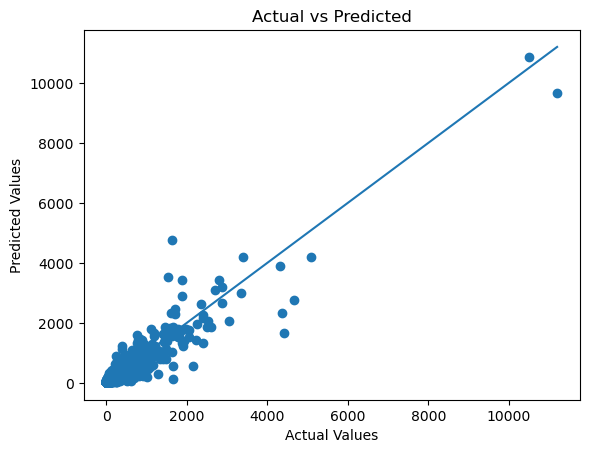

In [27]:
plt.figure()
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

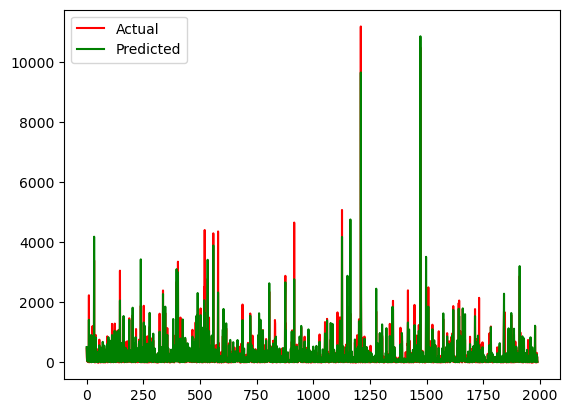

In [28]:
plt.figure()
plt.plot( y_test.values , label = "Actual", color = "red")
plt.plot(rf_preds , label="Predicted", color = "green")
plt.legend(loc= 'upper left')

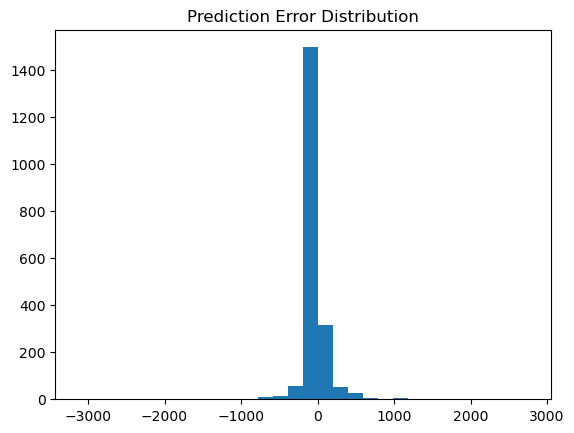

In [29]:
errors = y_test - rf_preds

plt.figure()
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.show()

# Business Insights

In [30]:
# Businesses should focus on high-margin products, not just increasing sales volume
# Businesses should avoid excessive discounting and instead use targeted promotions
# Discounts can be used strategically to increase demand during slow periods
# Increase inventory and staffing during high demand & Optimize costs during low demand